In [2]:
# 구글 드라이브 연동
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import json

with open("/content/drive/MyDrive/RAG/data/VL_01.Management_Female_Experienced/ckmk_d_bm_f_e_47108.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print(json.dumps(data, indent=2, ensure_ascii=False))  # 예시 하나 보기


{
  "version": "1.0",
  "dataSet": {
    "info": {
      "date": "20230116",
      "occupation": "BM",
      "channel": "MOCK",
      "place": "ONLINE",
      "gender": "FEMALE",
      "ageRange": "-34",
      "experience": "EXPERIENCED"
    },
    "question": {
      "raw": {
        "text": "본인이 태어나서 지금까지 가장 제일 후회했던 일은 무엇이라고 생각합니까",
        "wordCount": 9
      },
      "emotion": [],
      "intent": []
    },
    "answer": {
      "raw": {
        "text": "저는 태어나서 지금까지 후회하는 일로 실패가 두려워서 시도조차 못한 일들을 꼽고 싶습니다. 저는 살면서 다양한 실패들을 하였는데요. 어렸을 때는 실패들이 무가치하다고 생각을 하였지만 커서 보니 실패를 하더라도 시도를 하면 여러 가지 부분에서 배울 수 있는 점들이 참 많았고 또한 실패들을 통해 한층 더 성장할 수 있는 기회였다고 생각을 합니다. 다만 지금 과거의 저를 돌아봤을 때 실패가 두려워서 시도조차 안 한 일들은 어떤 결과가 나왔는지 예상을 할 수가 없고 또한 배울 수 있는 기회들을 잃어버렸기에 두고 두고 후회로 남는 것 같습니다. 감사합니다.",
        "wordCount": 81
      },
      "emotion": [
        {
          "text": "저는 태어나서 지금까지 후회하는 일로 실패가 두려워서 시도조차 못한 일들을 꼽고 싶습니다.",
          "expression": "n-distress",
          "category": "negative"
        },
        

In [ ]:
import os
import json
from tqdm import tqdm

def load_and_flatten_json(json_path):
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    info = data['dataSet']['info']
    question = data['dataSet']['question']['raw']['text']
    answer = data['dataSet']['answer']['raw']['text']
    summary = data['dataSet']['answer'].get('summary', {}).get('text', "")

    emotions = [
        emo.get('expression', '')
        for emo in data['dataSet']['answer'].get('emotion', [])
        if emo.get('expression', '')
    ]

    intents = [
        intent.get('category', '')
        for intent in data['dataSet']['answer'].get('intent', [])
        if intent.get('category', '')
    ]

    return {
        "question": question,
        "answer": answer,
        "metadata": {
            "occupation": info.get('occupation'),
            "gender": info.get('gender'),
            "experience": info.get('experience'),
            "date": info.get('date'),
            "emotion": emotions,
            "intent_category": intents,
            "summary": summary
        }
    }

def collect_all_data(root_dir):
    result = []
    for dirpath, _, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.endswith('.json'):
                file_path = os.path.join(dirpath, filename)
                try:
                    item = load_and_flatten_json(file_path)
                    result.append(item)
                except Exception as e:
                    print(f"Failed to load {file_path}: {e}")
    return result

# 경로 지정1
data_dir = '/content/drive/MyDrive/RAG/data'
output_path = '/content/drive/MyDrive/RAG/data/merged_interview_data.json'

# 실행
data = collect_all_data(data_dir)

# 저장
with open(output_path, 'w', encoding='utf-8') as f:
    for entry in data:
        json.dump(entry, f, ensure_ascii=False)
        f.write('\n')

print(f"✅ 총 {len(data)}개의 QA 데이터를 병합했습니다.")


Failed to load /content/drive/MyDrive/RAG/data/VL_06.Design_Female_Experienced/ckmk_d_ard_f_e_66661.json: Invalid control character at: line 34 column 165 (char 1573)
Failed to load /content/drive/MyDrive/RAG/data/VL_01.Management_Female_New/ckmk_d_bm_f_n_161564.json: Invalid control character at: line 23 column 100 (char 688)
✅ 총 8026개의 QA 데이터를 병합했습니다.


In [3]:
import json

jsonl_path = '/content/drive/MyDrive/RAG/data/merged_interview_data.json'

data = []
with open(jsonl_path, 'r', encoding='utf-8') as f:
    for line in f:
        data.append(json.loads(line))

print(f"총 샘플 수: {len(data)}")
print("샘플 예시:")
print(json.dumps(data[0], indent=2, ensure_ascii=False))


총 샘플 수: 8026
샘플 예시:
{
  "question": "지금 제일 가보고 싶은 회사는",
  "answer": "제가 이 회사에 지원한 이유는 지금 가장 가고 싶은 회사가 이 회사이기 때문입니다. 이 회사에서 근무를 하면서 더 많은 능력을 키우고 더 많은 경험을 통해서 제가 가고 싶었던 이 회사 회사를 회사에 좀 더 기여할 수 있도록 많은 노력을 하려고 하고 있습니다.",
  "metadata": {
    "occupation": "ARD",
    "gender": "FEMALE",
    "experience": "NEW",
    "date": "20230116",
    "emotion": [
      "p-interest",
      "p-interest"
    ],
    "intent_category": [
      "etc"
    ],
    "summary": "제가 이 회사에 지원한 이유는 가장 가고 싶은 회사이기 때문입니다. 회사에서 근무하며 회사에 기여할 수 있도록 노력을 하겠습니다."
  }
}


### 문장 길이 분포

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

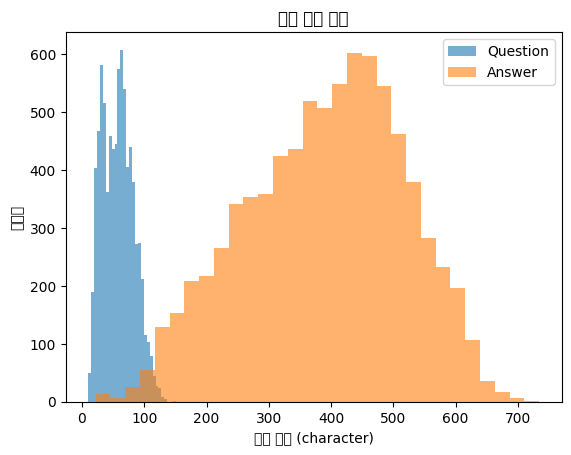

In [4]:
import matplotlib.pyplot as plt

question_lengths = [len(x['question']) for x in data]
answer_lengths = [len(x['answer']) for x in data]

plt.hist(question_lengths, bins=30, alpha=0.6, label='Question')
plt.hist(answer_lengths, bins=30, alpha=0.6, label='Answer')
plt.title("문장 길이 분포")
plt.xlabel("문장 길이 (character)")
plt.ylabel("빈도수")
plt.legend()
plt.show()


### 메타데이터 통계

In [5]:
from collections import Counter

occupations = Counter([x['metadata']['occupation'] for x in data])
genders = Counter([x['metadata']['gender'] for x in data])
experiences = Counter([x['metadata']['experience'] for x in data])

print("직군 분포:", occupations)
print("성별 분포:", genders)
print("경력 여부 분포:", experiences)

직군 분포: Counter({'PS': 2123, 'BM': 1897, 'SM': 1015, 'MM': 859, 'ARD': 812, 'ICT': 727, 'RND': 593})
성별 분포: Counter({'FEMALE': 4667, 'MALE': 3359})
경력 여부 분포: Counter({'NEW': 6889, 'EXPERIENCED': 1137})


### 감정 및 의도 태그 빈도

In [6]:
from itertools import chain

all_emotions = list(chain.from_iterable([x['metadata']['emotion'] for x in data]))
all_intents = list(chain.from_iterable([x['metadata']['intent_category'] for x in data]))

print("감정 표현 빈도:", Counter(all_emotions))
print("의도 카테고리 빈도:", Counter(all_intents))


감정 표현 빈도: Counter({'u-belief': 1334, 'u-fact': 1250, 'p-interest': 489, 'p-achievement': 179, 'n-distress': 153, 'p-happiness': 120, 'p-affection': 81, 'p-gratitude': 69, 'n-sadness': 33, 'n-anxiety': 30, 'n-anger': 12, 'n-shame': 11})
의도 카테고리 빈도: Counter({'attitude': 5655, 'background': 1693, 'personality': 1409, 'technology': 899, 'etc': 486})


데이터 구조 변환
```
{
  "id": "BM_FEMALE_47108",
  "context": "[질문] 본인이 태어나서 지금까지 가장 제일 후회했던 일은 무엇이라고 생각합니까\n[답변] 저는 태어나서 지금까지 후회하는 일로 실패가 두려워서 시도조차 못한 일들을 꼽고 싶습니다. ... 감사합니다.",
  "metadata": {
    "occupation": "BM",
    "gender": "FEMALE",
    "experience": "EXPERIENCED",
    "date": "20230116",
    "emotion": ["n-distress", "n-distress"],
    "intent_category": ["attitude"],
    "summary": "실패가 두려워 시도조차 못한 일들입니다..."
  }
}
```

In [7]:
import json
from tqdm import tqdm

input_path = '/content/drive/MyDrive/RAG/data/merged_interview_data.json'
output_path = '/content/drive/MyDrive/RAG/data/rag_chunks.json'

def make_rag_chunk(entry, idx):
    question = entry['question'].strip()
    answer = entry['answer'].strip()

    context = f"[질문] {question}\n[답변] {answer}"

    return {
        "id": f"entry_{idx}",
        "context": context,
        "metadata": entry['metadata']
    }

# 읽고 변환
rag_chunks = []
with open(input_path, 'r', encoding='utf-8') as f:
    for idx, line in enumerate(tqdm(f)):
        entry = json.loads(line)
        chunk = make_rag_chunk(entry, idx)
        rag_chunks.append(chunk)

# 저장
with open(output_path, 'w', encoding='utf-8') as f:
    for chunk in rag_chunks:
        json.dump(chunk, f, ensure_ascii=False)
        f.write('\n')

print(f"총 {len(rag_chunks)}개의 QA 청크를 저장했습니다.")


8026it [00:00, 20767.01it/s]


총 8026개의 QA 청크를 저장했습니다.
